In [1]:
import numpy as np

scaling, translation, and perspective transformations.

In [2]:
def scaling_transformation(points, scale_factors):
    """
    Apply scaling transformation to a set of points using homogeneous coordinates.

    Parameters:
    points (np.ndarray): An array of points with shape (n_points, 2).
    scale_factors (tuple): Scaling factors (sx, sy) for each axis.

    Returns:
    np.ndarray: Transformed points.
    """
    sx, sy = scale_factors
    scaling_matrix = np.array([
        [sx, 0,  0],
        [0,  sy, 0],
        [0,  0,  1]
    ])

    # Convert points to homogeneous coordinates
    points_homogeneous = np.hstack((points, np.ones((points.shape[0], 1))))
    # Apply the scaling transformation
    transformed_points_homogeneous = points_homogeneous.dot(scaling_matrix.T)
    # Convert back to Cartesian coordinates
    transformed_points = transformed_points_homogeneous[:, :-1]

    return transformed_points

# Example usage
points = np.array([
    [1, 2],
    [4, 5],
    [7,8]
])

scale_factors = (2, 2)
transformed_points = scaling_transformation(points, scale_factors)
print(transformed_points)

[[ 2.  4.]
 [ 8. 10.]
 [14. 16.]]


In [3]:
def translation_transformation(points, translation_factors):
    """
    Apply translation transformation to a set of points using homogeneous coordinates.

    Parameters:
    points (np.ndarray): An array of points with shape (n_points, 2).
    translation_factors (tuple): Translation factors (tx, ty) for each axis.

    Returns:
    np.ndarray: Transformed points.
    """
    tx, ty = translation_factors
    translation_matrix = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

    # Convert points to homogeneous coordinates
    points_homogeneous = np.hstack((points, np.ones((points.shape[0], 1))))

    # Apply the translation transformation
    transformed_points_homogeneous = points_homogeneous.dot(translation_matrix.T)

    # Convert back to Cartesian coordinates
    transformed_points = transformed_points_homogeneous[:, :-1]

    return transformed_points

# Example usage
translation_factors = (3, 3)
translated_points = translation_transformation(points, translation_factors)
print(translated_points)

[[ 4.  5.]
 [ 7.  8.]
 [10. 11.]]


In [4]:
def perspective_transformation(points, perspective_factors):
    """
    Apply perspective transformation to a set of points using homogeneous coordinates.

    Parameters:
    points (np.ndarray): An array of points with shape (n_points, 2).
    perspective_factors (tuple): Perspective factors (px, py) for each axis.

    Returns:
    np.ndarray: Transformed points.
    """
    px, py = perspective_factors
    perspective_matrix = np.array([
        [1, 0, 0],
        [0, 1, 0],
        [px, py, 1]
    ])

    # Convert points to homogeneous coordinates
    points_homogeneous = np.hstack((points, np.ones((points.shape[0], 1))))

    # Apply the perspective transformation
    transformed_points_homogeneous = points_homogeneous.dot(perspective_matrix.T)

    # Convert back to Cartesian coordinates
    transformed_points = transformed_points_homogeneous[:, :-1] / transformed_points_homogeneous[:, -1][:, np.newaxis]

    return transformed_points

# Example usage
perspective_factors = (0.1, 0.1)
perspective_transformed_points = perspective_transformation(points, perspective_factors)
print(perspective_transformed_points)

[[0.76923077 1.53846154]
 [2.10526316 2.63157895]
 [2.8        3.2       ]]


In [5]:
def rotation_transformation(points, angle_deg, center=None):
    """
    使用齐次坐标对二维点集进行旋转（逆时针为正）。
    - points: (N, 2) numpy 数组
    - angle_deg: 旋转角度（度）
    - center: 旋转中心 (cx, cy)，默认 (0, 0)
    返回: (N, 2) 数组
    """
    points_homogeneous = np.hstack((points, np.ones((points.shape[0], 1))))
    if center is None:
        cx, cy = 0.0, 0.0
    else:
        cx, cy = map(float, center)

    theta = np.deg2rad(angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)

    # 齐次矩阵：T(cx,cy) · R(theta) · T(-cx,-cy)
    T1 = np.array([[1, 0, -cx],
                   [0, 1, -cy],
                   [0, 0,   1 ]], dtype=float)

    R = np.array([[ cos_t, -sin_t, 0],
                  [ sin_t,  cos_t, 0],
                  [    0 ,     0 , 1]], dtype=float)

    T2 = np.array([[1, 0, cx],
                   [0, 1, cy],
                   [0, 0,  1]], dtype=float)

    M = T2 @ R @ T1  # 总变换矩阵（3x3）

    transformed_points_homogeneous = points_homogeneous @ M.T
    transformed_points = transformed_points_homogeneous[:, :2]

    return transformed_points
rotated_points = rotation_transformation(points, 90, center=(0, 0))
print(rotated_points)

[[-2.  1.]
 [-5.  4.]
 [-8.  7.]]


In [6]:
def shear_transformation(points, shx=0.0, shy=0.0, center=None):
    """
    对二维点集进行剪切（Shear）变换。
    参数：
    - points: (N, 2) numpy 数组
    - shx: 沿 x 方向的剪切系数（y 越大，x 偏移越大）
    - shy: 沿 y 方向的剪切系数（x 越大，y 偏移越大）
    - center: 剪切中心 (cx, cy)，默认 (0, 0)
    """
    points_homogeneous = np.hstack((points, np.ones((points.shape[0], 1))))
    if center is None:
        cx, cy = 0.0, 0.0
    else:
        cx, cy = map(float, center)

    T1 = np.array([[1, 0, -cx],
                   [0, 1, -cy],
                   [0, 0,   1 ]], dtype=float)

    Sh = np.array([[1,  shx, 0],
                   [shy, 1 , 0],
                   [0,   0 , 1]], dtype=float)

    T2 = np.array([[1, 0, cx],
                   [0, 1, cy],
                   [0, 0,  1]], dtype=float)

    M = T2 @ Sh @ T1  # 总变换矩阵（3x3）

    transformed_points_homogeneous = (M @ points_homogeneous.T).T
    transformed_points = transformed_points_homogeneous[:, :2]
    return transformed_points
shear_points = shear_transformation(points, 0.5, 0.3, center=(0, 0))
print(shear_points)

[[ 2.   2.3]
 [ 6.5  6.2]
 [11.  10.1]]


In [7]:
def affine_transformation(points, A=None, translation=(0, 0)):
    """
    对二维点集进行齐次坐标下的通用仿射变换。

    参数：
    - points: (N, 2) numpy 数组
    - A: 2x2 线性部分矩阵（控制旋转/缩放/错切），默认单位矩阵
    - translation: (tx, ty) 平移向量
    返回：
    - (N, 2) numpy 数组：变换后的点集
    """
    points_homogeneous = np.hstack((points, np.ones((points.shape[0], 1))))
    if A is None:
        A = np.eye(2)
    tx, ty = translation

    M = np.array([
        [A[0, 0], A[0, 1], tx],
        [A[1, 0], A[1, 1], ty],
        [0, 0, 1]
    ], dtype=float)

    transformed_points_homogeneous = (M @ points_homogeneous.T).T

    return transformed_points_homogeneous[:, :2]

A = np.array([
    [1.2, 0.3],   # x轴放大1.2倍，x方向错切0.3
    [0.1, 0.9]    # y轴缩放0.9倍，y方向错切0.1
])
affine_points = affine_transformation(points,A, (1, 2))
print(affine_points)

[[ 2.8  3.9]
 [ 7.3  6.9]
 [11.8  9.9]]


### in image processing

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

def affine_image_transform(img, A=None, translation=(0, 0), resample=Image.BICUBIC):
    """
    对图像执行齐次坐标下的仿射变换。

    参数：
    - img: Pillow Image 对象
    - A: 2x2 仿射矩阵，控制旋转/缩放/错切
    - translation: (tx, ty)，平移向量
    - resample: 插值方式（默认双三次）

    返回：
    - 变换后的 Pillow 图像
    """
    if A is None:
        A = np.eye(2)
    tx, ty = translation

    # 构造 3x3 齐次矩阵
    M = np.array([
        [A[0,0], A[0,1], tx],
        [A[1,0], A[1,1], ty],
        [0, 0, 1]
    ], dtype=float)

    # Pillow 需要逆矩阵（输出->输入）
    M_inv = np.linalg.inv(M)

    # 提取前两行的前3列
    coeffs = (M_inv[0,0], M_inv[0,1], M_inv[0,2],
              M_inv[1,0], M_inv[1,1], M_inv[1,2])

    # 执行仿射变换
    transformed_img = img.transform(img.size, Image.AFFINE, coeffs, resample=resample)
    return transformed_img

def compose_centered_affine(A2x2, translation=(0,0), center=(0,0)):
    A = np.asarray(A2x2, dtype=float)
    tx, ty = translation
    cx, cy = center
    T_neg = np.array([[1,0,-cx],[0,1,-cy],[0,0,1]], float)
    T_pos = np.array([[1,0, cx],[0,1, cy],[0,0,1]], float)
    A_h = np.array([[A[0,0], A[0,1], 0],
                    [A[1,0], A[1,1], 0],
                    [0,      0,      1]], float)
    T_tr = np.array([[1,0,tx],[0,1,ty],[0,0,1]], float)
    M = T_tr @ T_pos @ A_h @ T_neg
    return M[:2,:2], (M[0,2], M[1,2])

def compare(title, original, transformed):
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1); plt.imshow(original); plt.title("Original"); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(transformed); plt.title(title);  plt.axis('off')
    plt.show()

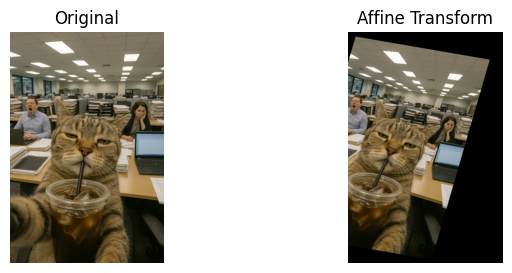

In [9]:
img = Image.open("../src/data/image/test_img.png")

# 示例：旋转 + 缩放 + 平移 + 错切
theta = np.deg2rad(30)
A = np.array([
    [1.0*np.cos(theta), -0.5*np.sin(theta)],  # 缩放 + 旋转 + x错切
    [0.3*np.sin(theta),  1.0*np.cos(theta)]   # y错切
])

transformed = affine_image_transform(img, A, translation=(50, 30))
compare("Affine Transform", img, transformed)

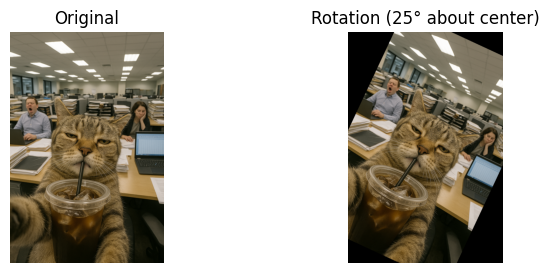

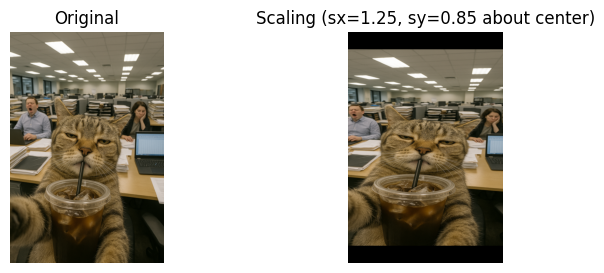

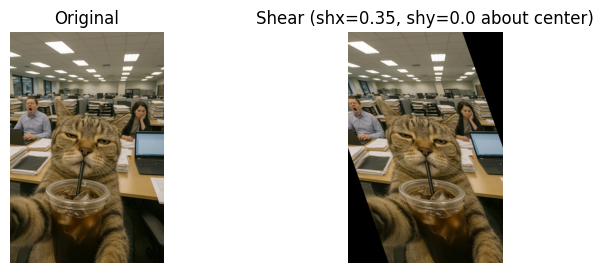

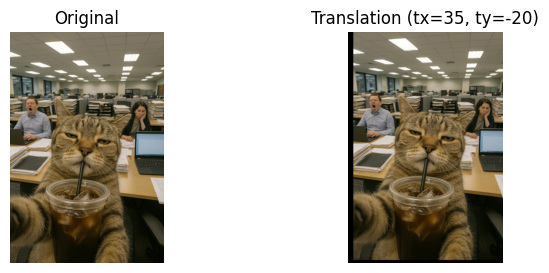

In [10]:
angle_deg = 25
theta = np.deg2rad(angle_deg)
A_rot = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
w, h = img.size
center = (w/2, h/2)
A_use, t_use = compose_centered_affine(A_rot, translation=(0,0), center=center)
img_rot = affine_image_transform(img, A_use, t_use)
compare(f"Rotation ({angle_deg}° about center)", img, img_rot)

# 2) Scaling about center
sx, sy = 1.25, 0.85
A_scl = np.array([[sx, 0],
                  [0, sy]])
A_use_s, t_use_s = compose_centered_affine(A_scl, translation=(0,0), center=center)
img_scl = affine_image_transform(img, A_use_s, t_use_s)
compare(f"Scaling (sx={sx}, sy={sy} about center)", img, img_scl)

# 3) Shear about center
shx, shy = 0.35, 0.0
A_sh = np.array([[1, shx],
                 [shy, 1]])
A_use_sh, t_use_sh = compose_centered_affine(A_sh, translation=(0,0), center=center)
img_sh = affine_image_transform(img, A_use_sh, t_use_sh)
compare(f"Shear (shx={shx}, shy={shy} about center)", img, img_sh)

# 4) Translation
t = (35, -20)
img_tr = affine_image_transform(img, np.eye(2), t)
compare(f"Translation (tx={t[0]}, ty={t[1]})", img, img_tr)